# Linear Regression Model 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [4]:
df = pd.read_csv(r'c:\Users\riyar\OneDrive\Desktop\MachineLearning2026_Riya\MachineLearning2026_Riya\Assignments\HR_Employee.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Feature Selection


In [ ]:
features = [
    'Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 
    'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 
    'JobLevel', 'JobRole', 'JobSatisfaction', 'MonthlyIncome', 'OverTime', 
    'TotalWorkingYears'
]
target = 'Attrition'

df_selected = df[features + [target]].copy()
df_selected.head()

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MonthlyIncome,OverTime,TotalWorkingYears,Attrition
0,41,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,2,Sales Executive,4,5993,Yes,8,Yes
1,49,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,2,Research Scientist,2,5130,No,10,No
2,37,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,1,Laboratory Technician,3,2090,Yes,7,Yes
3,33,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,1,Research Scientist,3,2909,Yes,8,No
4,27,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,1,Laboratory Technician,2,3468,No,6,No


## 3. Data Preprocessing

In [ ]:
df_selected['Attrition'] = df_selected['Attrition'].map({'Yes': 1, 'No': 0})

X = df_selected.drop('Attrition', axis=1)
y = df_selected['Attrition']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_encoded.head()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,TotalWorkingYears,BusinessTravel_Travel_Frequently,...,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,OverTime_Yes
0,41,1,2,2,3,2,4,5993,8,False,...,False,False,False,False,False,False,False,True,False,True
1,49,8,1,3,2,2,2,5130,10,True,...,True,False,False,False,False,False,True,False,False,False
2,37,2,2,4,2,1,3,2090,7,False,...,True,False,True,False,False,False,False,False,False,True
3,33,3,4,4,3,1,3,2909,8,True,...,False,False,False,False,False,False,True,False,False,True
4,27,2,1,1,3,1,2,3468,6,False,...,True,False,True,False,False,False,False,False,False,False


## 4. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape: {X_test.shape}')

Training data shape: (1176, 28)
Testing data shape: (294, 28)


## 5. Build and Train Linear Regression Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


## 6. Predictions and Evaluation

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.1057
Root Mean Squared Error (RMSE): 0.3250
R-squared (R2): 0.0817


## 7. Results Visualization

Plot the actual vs predicted values.

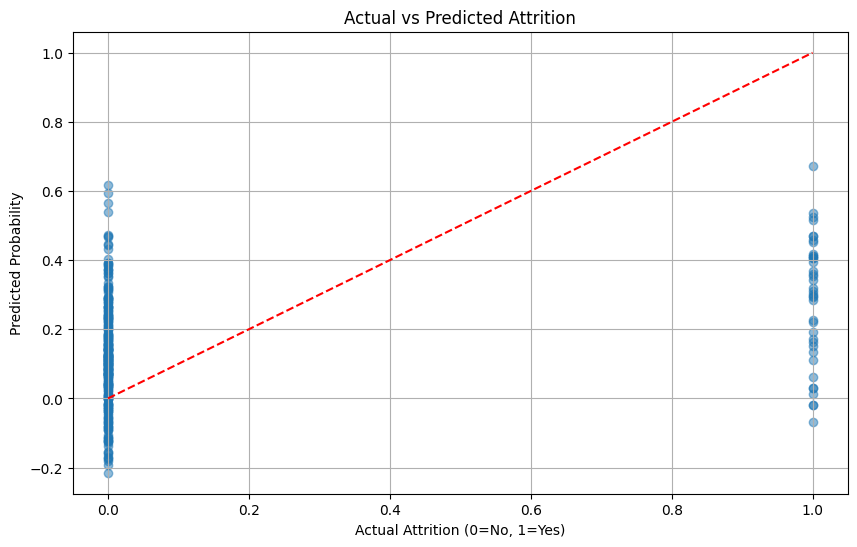

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel("Actual Attrition (0=No, 1=Yes)")
plt.ylabel("Predicted Probability")
plt.title("Actual vs Predicted Attrition")
plt.grid(True)
plt.show()